# Force Prediction

Machine learning model and data pipeline for predicting profile at any given MVC level from motor neuron activations.

## Preprocessing

Sanitize and prepare all the data for the machine learning model. This is a crucial step in the machine learning pipeline. The quality of the data and the features used in the model will determine the model's performance.

### Conversion

Convert, process, and export processed original data to a more structured and useful format (pandas DataFrame).

In [120]:
import importlib
import processing.conversion

importlib.reload(processing.conversion)

from processing.conversion import Conversion

c = Conversion(prefix='processing', subjects=["iatroudelis"])

c.cleanup_data() # cleans the data directory and prepares for processing
c.process_subjects(replace=False) # processes each subject and exports to txt files

Skipping iatroudelis as raw folder already exists

Processing data for iatroudelis
	Skipping 10.1.mat as it has already been processed
	Skipping 10.3.mat as it has already been processed
	Skipping 20.1.mat as it has already been processed
	Skipping 20.2.mat as it has already been processed
	Skipping 20.3.mat as it has already been processed
	Skipping 40.1.mat as it has already been processed
	Skipping 40.2.mat as it has already been processed
	Skipping 40.3.mat as it has already been processed
	Skipping 5.1.mat as it has already been processed
	Skipping 5.2.mat as it has already been processed
	Skipping 5.3.mat as it has already been processed
	Skipping 60.1.mat as it has already been processed
	Skipping 60.2.mat as it has already been processed
	Skipping 60.3.mat as it has already been processed
	Processing MVC.1.mat (MVC: 100, Trial: 1)...
	Processing MVC.2.mat (MVC: 100, Trial: 2)...
	Successfully processed data for iatroudelis


In [121]:
df = c.get_dataframe() # returns a pandas dataframe of the processed data
df

Loading data for iatroudelis...


,subject,mvc_level,trial_number,neuron_data,force_data
0,iatroudelis,5,1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, -0.006100465392307797, 0.0, -0.006100465..."
1,iatroudelis,5,2,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, -0.006100465392307797, -0.00610046539230..."
2,iatroudelis,5,3,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.006100465392307797, 0.0, 0.00610046539..."
3,iatroudelis,10,1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.012200930784615593, 0.0122009307846155..."
4,iatroudelis,10,3,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.006100465392307797, 0.0, 0.00610046539..."
5,iatroudelis,20,1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, -0.006100465392307797, -0.01220093078461..."
6,iatroudelis,20,2,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.012200930784601383, 0.0, 0.0, 0.0, 0.0..."
7,iatroudelis,20,3,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.012200930784615593, 0.0122009307846155..."
8,iatroudelis,40,1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.01830139617690918, 0.00610046539230779..."
9,iatroudelis,40,2,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.0, -0.012200930784601383, -0.012200930..."


### Sanitization

Remove or correct any errors in the data. This includes removing outliers, filling in missing values, and correcting any other errors in the data. Some entries are not recoverable and will be "purged".

More information and specific algorithm implementations can be found [here](https://github.com/paul-bokelman/force-prediction/issues/3).

In [122]:
import importlib
import processing.sanitization
import processing.constants

importlib.reload(processing.sanitization)
importlib.reload(processing.constants)

from processing.sanitization import Sanitization

sanitizer = Sanitization(df=df)
df = sanitizer.sanitize()
df

Computing global statistics...
	Average max activation distance: 10673.0
	Max force data length: 89747
	Max number of neurons: 25
	Max number of activations: 89747
Global statistics computed.
Purging entries with insufficient neuron data...
Purged 2 entries with insufficient neuron data. 14 entries remaining.
Handling measurement correlation...
[iatroudelis.5.1] Identified flat region @ 0.0 - 4.1748046875: -7.491799604582705e-06
[iatroudelis.5.1] Identified flat region @ 4.1748046875 - 8.349609375: 0.00011166348934450569
[iatroudelis.5.1] Identified flat region @ 8.349609375 - 12.5244140625: 7.135047242473569e-07
[iatroudelis.5.1] Identified flat region @ 12.5244140625 - 16.69970703125: -2.1402638494814973e-06
[iatroudelis.5.1] Identified flat region @ 16.69970703125 - 20.87451171875: 7.135047242460273e-06
[iatroudelis.5.1] Identified flat region @ 20.87451171875 - 25.04931640625: -1.3199837398549927e-05
[iatroudelis.5.1] Identified flat region @ 25.04931640625 - 29.224609375: -2.85368

,subject,mvc_level,trial_number,neuron_data,force_data
0,iatroudelis,5,1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, -0.006100465392307797, 0.0, -0.006100465..."
1,iatroudelis,5,2,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, -0.006100465392307797, -0.00610046539230..."
2,iatroudelis,5,3,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.006100465392307797, 0.0, 0.00610046539..."
3,iatroudelis,10,1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.012200930784615593, 0.0122009307846155..."
4,iatroudelis,10,3,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.006100465392307797, 0.0, 0.00610046539..."
5,iatroudelis,20,1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, -0.006100465392307797, -0.01220093078461..."
6,iatroudelis,20,2,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.012200930784601383, 0.0, 0.0, 0.0, 0.0..."
7,iatroudelis,20,3,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.012200930784615593, 0.0122009307846155..."
8,iatroudelis,40,1,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.01830139617690918, 0.00610046539230779..."
9,iatroudelis,40,2,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, 0.0, -0.012200930784601383, -0.012200930..."


In [123]:
sanitizer.show_purged()

,subject,mvc_level,trial_number
14,iatroudelis,100,1
15,iatroudelis,100,2


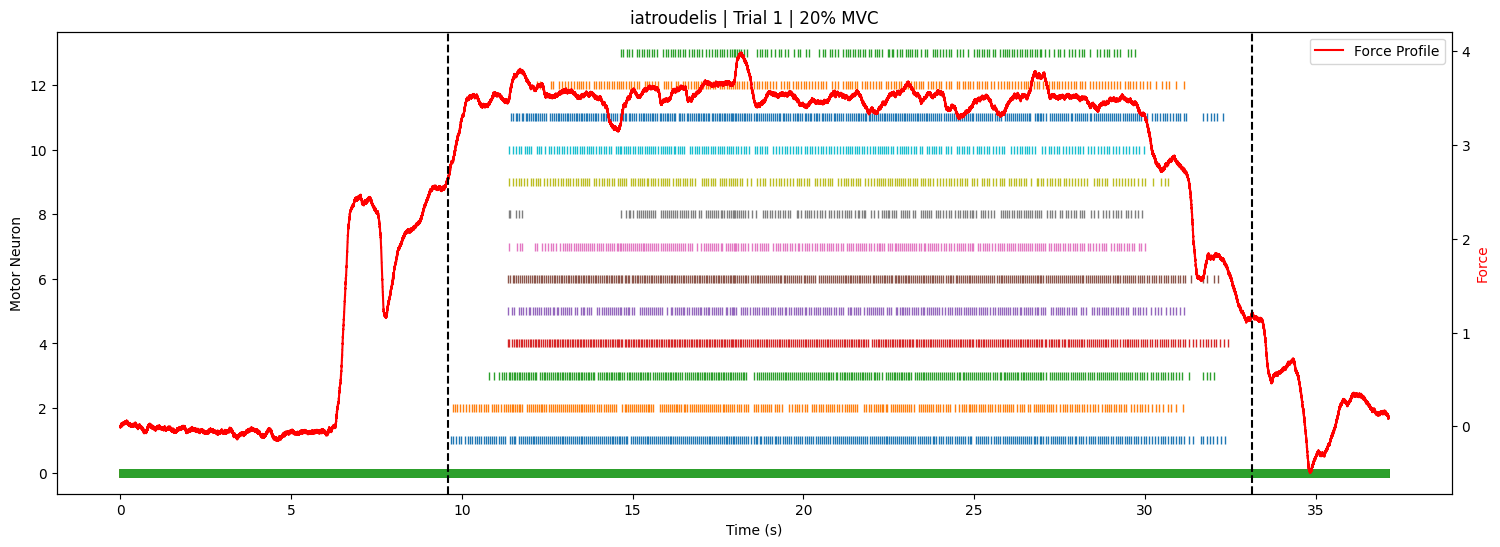

In [124]:
import globals.visualization
importlib.reload(globals.visualization)
from globals.visualization import visualize_trial

visualize_trial(df=df, subject="iatroudelis", mvc_level=20, trial_number=1, vmarkers=[9.58544921875, 33.1376953125])